# 08. Districts: polygon AOIs and zonal statistics

A city is not a rectangle, and the question is often "how hot does each district get" rather than "how hot is this pixel". This notebook uses the official Berlin district boundaries to:

1. turn the city outline into a polygon AOI (`AOI.from_geometry`) and see what it changes against the bounding box;
2. blank everything outside the city with `clip_to_aoi`;
3. summarise the 100 m downscaled temperature of notebook 04 per district and per scene with `zonal_statistics`;
4. write the results as CSV and GeoJSON for a spreadsheet or GIS software.

Run notebook 04 first: this one reads its saved result from `output/notebooks/04_export/`.

The boundaries come from the State of Berlin's geodata service ([gdi.berlin.de](https://gdi.berlin.de), ALKIS district boundaries, open data under the dl-de/zero-2.0 licence), requested once and kept next to the other outputs.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dotenv import dotenv_values, load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "output" / "notebooks"
WORK = OUT / "work"  # shared download/subset cache: later notebooks reuse it
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Credentials live in the repository's .env (see docs/setup.md). The
# Earthdata token is often kept only in worker/.env; fall back to it.
load_dotenv(ROOT / ".env")
if not os.getenv("EARTHDATA_BEARER_TOKEN"):
    token = dotenv_values(ROOT / "worker" / ".env").get("EARTHDATA_BEARER_TOKEN")
    if token:
        os.environ["EARTHDATA_BEARER_TOKEN"] = token

# Upstream notices (numpy/xarray/matplotlib internals, all-NaN slices of
# cloudy scenes) that say nothing about the analysis.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False, "image.origin": "upper"})
pd.set_option("display.max_colwidth", 70)

In [2]:
def extent_km(da):
    """imshow extent of a projected y/x grid, in kilometres."""
    x, y = da["x"].values, da["y"].values
    dx, dy = abs(x[1] - x[0]), abs(y[1] - y[0])
    return [(x.min() - dx / 2) / 1e3, (x.max() + dx / 2) / 1e3, (y.min() - dy / 2) / 1e3, (y.max() + dy / 2) / 1e3]


def show_map(ax, da, title, cmap="inferno", label=None, vmin=None, vmax=None):
    """One georeferenced map with a colour bar; axes in UTM kilometres."""
    image = ax.imshow(da.values, extent=extent_km(da), cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("easting (km)")
    ax.set_ylabel("northing (km)")
    plt.colorbar(image, ax=ax, shrink=0.8, label=label or da.attrs.get("units", ""))
    return image

In [3]:
import dataclasses
import json

import requests
import shapely
import shapely.ops
from pyproj import Transformer
from shapely.geometry import shape

import sentinel_analysis as sa

DISTRICTS = OUT / "berlin_districts.geojson"
if not DISTRICTS.exists():
    response = requests.get(
        "https://gdi.berlin.de/services/wfs/alkis_bezirke",
        params={"service": "WFS", "version": "2.0.0", "request": "GetFeature", "typeNames": "alkis_bezirke:bezirksgrenzen",
                "outputFormat": "application/json", "srsName": "EPSG:4326"},
        timeout=60,
    )
    response.raise_for_status()
    DISTRICTS.write_text(response.text, encoding="utf-8")
districts = json.loads(DISTRICTS.read_text(encoding="utf-8"))
pd.DataFrame([feature["properties"] for feature in districts["features"]])[["namgem", "gem"]].T

,0,1,2,3,4,5,6,7,8,9,10,11
namgem,Mitte,Friedrichshain-Kreuzberg,Pankow,Charlottenburg-Wilmersdorf,Spandau,Steglitz-Zehlendorf,Tempelhof-Schöneberg,Neukölln,Treptow-Köpenick,Marzahn-Hellersdorf,Lichtenberg,Reinickendorf
gem,001,002,003,004,005,006,007,008,009,010,011,012


## 1. A polygon AOI

`AOI.from_geojson` merges all features into one shape. These official boundaries are surveyed to the centimetre, with about 28 000 vertices, which is more than `MAX_AOI_VERTICES` allows: every mask, coverage computation and cloud probe would pay for that detail, and a request carrying it would be several hundred kilobytes. The AOI refuses it and asks for a simplified outline:

In [4]:
try:
    sa.AOI.from_geojson(DISTRICTS)
except ValueError as error:
    print("refused:", error)

city = shapely.unary_union([shape(feature["geometry"]) for feature in districts["features"]])
outline = shapely.simplify(city, tolerance=0.0005)  # about 35 m in latitude, far below a 100 m cell
aoi = sa.AOI.from_geometry(shapely.geometry.mapping(outline))
print(f"vertices: {shapely.get_num_coordinates(city):,} -> {shapely.get_num_coordinates(outline):,}")
print(f"bounding box: {aoi.west:.3f}, {aoi.south:.3f}, {aoi.east:.3f}, {aoi.north:.3f}")

refused: The AOI polygons have more than 10000 vertices; simplify them first


vertices: 9,581 -> 486
bounding box: 13.088, 52.338, 13.761, 52.676


The catalogue is still searched with the bounding box, and the cubes are still rectangular grids over it. What the polygon changes is everything that depends on the shape:

* how much of the AOI a product covers (`min_aoi_coverage`), so a pass that only clips the box corner outside the city no longer counts;
* the Sentinel-3 clear-sky probe (`min_clear_fraction`), which now measures clouds over the city only;
* the downscaled output, which is blanked outside the polygon.

The polygon travels with the request, so it is stored in `request.json` and accepted by the worker API (its map sends any non-rectangular drawing):

In [5]:
berlin = sa.get_city("berlin")
request = sa.AnalysisRequest.for_city(berlin, "2026-08-01", "2026-08-21", sensors=("sentinel3", "sentinel2"), resolution_m=100)
request = dataclasses.replace(request, aoi=aoi, min_aoi_coverage=0.5, min_clear_fraction=0.3,
                              downscale=sa.DownscaleSpec())
as_json = request.to_dict()
print(as_json["aoi"]["geometry"]["type"], "with", len(json.dumps(as_json["aoi"])) // 1000, "kB of coordinates")
assert sa.AnalysisRequest.from_dict(as_json).aoi == aoi

MultiPolygon with 13 kB of coordinates


## 2. Clipping to the city

`aoi_mask` marks the grid cells whose centre lies inside the polygon; `clip_to_aoi` blanks everything else. Here it is applied to the result of notebook 04. That run used the library's built-in Berlin AOI, a box over the centre of the city (about 24 x 21 km), so the polygon trims its edges and the outer districts are only partly inside it.

95% of the notebook 04 grid (501 km2) lies inside the city


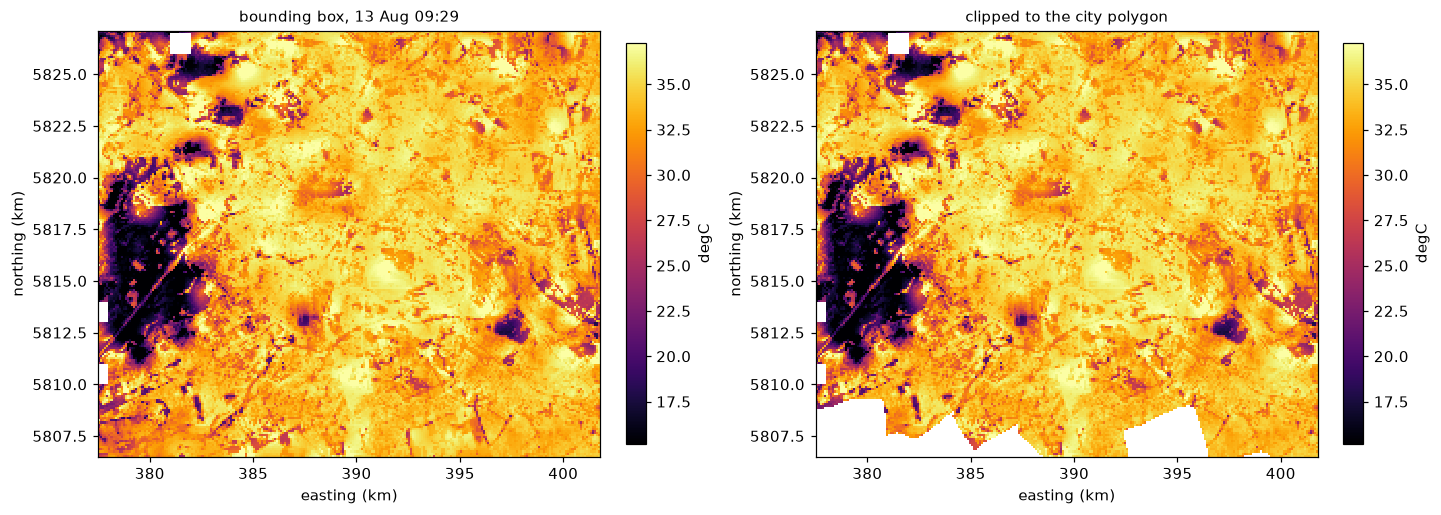

In [6]:
downscaled = sa.open_zarr(OUT / "04_export" / "result" / "downscaled.zarr")
lst = downscaled["lst_downscaled"]
inside = sa.aoi_mask(lst, aoi)
print(f"{float(inside.mean()):.0%} of the notebook 04 grid ({inside.size * 0.01:.0f} km2) lies inside the city")

coverage = lst.notnull().where(inside).mean(["y", "x"]).compute()
scene = int(coverage.argmax())
clearest = lst.isel(time=scene).load()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
low, high = np.nanpercentile(clearest.values, [2, 98])
show_map(axes[0], clearest, f"bounding box, {pd.Timestamp(clearest.time.values):%d %b %H:%M}", label="degC", vmin=low, vmax=high)
show_map(axes[1], sa.clip_to_aoi(clearest, aoi), "clipped to the city polygon", label="degC", vmin=low, vmax=high)
fig.savefig(FIGURES / "08_clip.png", bbox_inches="tight")
plt.show()

## 3. Statistics per district

`ZoneSet.from_geojson` reads the districts (here named by `namgem`); `zonal_statistics` returns one row per district and scene. Zone membership is computed once for the grid, and the scenes are read one at a time, so the lazily opened Zarr store is never loaded whole.

`count` matters as much as the mean: it is the number of 100 m cells with a value, so a district under clouds shows a small count instead of a mean computed from a few cells at its edge.

In [7]:
zones = sa.ZoneSet.from_geojson(DISTRICTS, id_field="namgem")
table = sa.zonal_statistics(lst, zones, statistics=("count", "mean", "p90"))
cells_per_district = pd.Series((zones.labels(lst).values[..., None] == np.arange(len(zones))).sum((0, 1)), index=zones.ids)
table["clear_fraction"] = table["count"] / table["zone"].map(cells_per_district)

# How much of each district the grid holds (areas in a projected CRS, not degrees).
to_grid = lambda geometry: shapely.ops.transform(Transformer.from_crs("EPSG:4326", lst.attrs["crs"], always_xy=True).transform, geometry)
district_km2 = pd.Series([to_grid(geometry).area / 1e6 for geometry in zones.shapes()], index=zones.ids)
pd.DataFrame({"km2 in grid": cells_per_district * 0.01, "district km2": district_km2, "share in grid": cells_per_district * 0.01 / district_km2}).round(2)

,km2 in grid,district km2,share in grid
Mitte,39.33,39.38,1.00
Friedrichshain-Kreuzberg,20.38,20.39,1.00
Pankow,36.29,103.16,0.35
Charlottenburg-Wilmersdorf,63.17,64.66,0.98
Spandau,27.14,91.84,0.30
Steglitz-Zehlendorf,69.11,102.51,0.67
Tempelhof-Schöneberg,45.91,53.02,0.87
Neukölln,44.65,44.91,0.99
Treptow-Köpenick,39.91,167.64,0.24
Marzahn-Hellersdorf,13.58,61.78,0.22


`table` has one row per district and scene. Only scene and district pairs with at least 80 % of the district's grid cells observed are compared, so a mean is never computed from a cloud-free corner. Then the district ranking is consistent across the clear scenes:

In [8]:
clear = table[table["clear_fraction"] >= 0.8]
by_scene = clear.pivot(index="time", columns="zone", values="mean")
anomaly = by_scene.sub(by_scene.mean(axis=1), axis=0)  # remove each day's city-wide level
summary = pd.DataFrame({
    "clear scenes": clear.groupby("zone").size(),
    "mean LST (degC)": clear.groupby("zone")["mean"].mean(),
    "anomaly vs city (K)": anomaly.mean(),
    "hottest 10 % (degC)": clear.groupby("zone")["p90"].mean(),
}).sort_values("anomaly vs city (K)", ascending=False)
summary.round(2)

,clear scenes,mean LST (degC),anomaly vs city (K),hottest 10 % (degC)
zone,,,,
Tempelhof-Schöneberg,12,34.26,1.54,36.37
Friedrichshain-Kreuzberg,11,34.42,1.52,36.23
Neukölln,11,34.06,0.85,36.08
Mitte,11,33.95,0.75,35.99
Lichtenberg,9,33.21,0.41,35.65
Pankow,11,33.01,0.38,35.08
Marzahn-Hellersdorf,10,32.45,0.32,34.68
Treptow-Köpenick,9,32.35,-0.45,35.49
Reinickendorf,10,31.76,-1.06,36.65


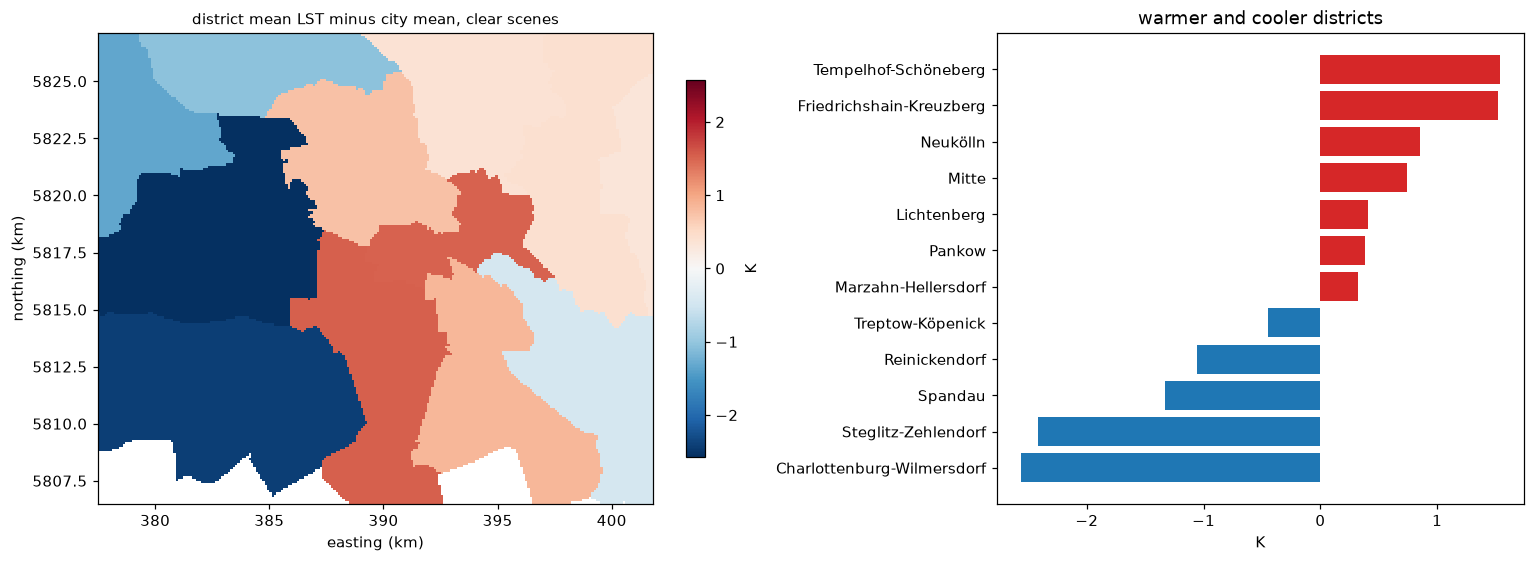

In [9]:
labels = zones.labels(lst)
anomaly_map = xr.full_like(labels, np.nan, dtype=float)
for index, zone in enumerate(zones.ids):
    if zone in summary.index:
        anomaly_map = anomaly_map.where(labels != index, summary.loc[zone, "anomaly vs city (K)"])
anomaly_map.attrs["crs"] = lst.attrs.get("crs")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True, gridspec_kw={"width_ratios": [1.25, 1]})
limit = float(np.nanmax(np.abs(anomaly_map.values)))
show_map(axes[0], anomaly_map, "district mean LST minus city mean, clear scenes", cmap="RdBu_r", label="K", vmin=-limit, vmax=limit)
ordered = summary["anomaly vs city (K)"].sort_values()
axes[1].barh(ordered.index, ordered.values, color=["tab:blue" if value < 0 else "tab:red" for value in ordered.values])
axes[1].set_xlabel("K")
axes[1].set_title("warmer and cooler districts")
fig.savefig(FIGURES / "08_districts.png", bbox_inches="tight")
plt.show()

In August 2026 the dense inner districts ran warmest by day: Tempelhof-Schoeneberg and Friedrichshain-Kreuzberg about 1.5 K above the city mean, then Neukoelln and Mitte. Charlottenburg-Wilmersdorf and Steglitz-Zehlendorf, which hold the Grunewald forest and the Havel lakes, ran about 2.5 K below it. The ranking is stable from scene to scene, which is what makes it a property of the districts rather than of one day's weather.

Two cautions. The outer districts are only partly inside the grid (the share is in the table of section 3), so their numbers describe that part. And the mean hides contrasts inside a district: Reinickendorf is cool on average but has the highest 90th percentile of all; the part inside the grid includes the former Tegel airport, a large open sealed surface. The `p90` column, or `max`, catches such hot spots.

## 4. Writing the results

The long table goes to CSV; `ZoneSet.to_geojson` writes the district outlines with one property per scene (`mean_<scene time>`), ready for QGIS or a web map.

In [10]:
export = OUT / "08_export"
export.mkdir(parents=True, exist_ok=True)
table.to_csv(export / "district_lst.csv", index=False)
written = zones.to_geojson(table, export / "district_lst.geojson", value="mean")
properties = json.loads(written.read_text())["features"][0]["properties"]
print(f"{written.name}: {written.stat().st_size / 1e6:.1f} MB, properties of the first district: {list(properties)[:4]} ...")

district_lst.geojson: 0.8 MB, properties of the first district: ['name', 'gem', 'namgem', 'namlan'] ...


## Next

Run the same districts over a whole summer with the worker API of notebook 06 (submit the polygon as `aoi.geometry`), or replace the districts by any other GeoJSON: parks, neighbourhoods, a buffer around schools.